mambajs 0.21.1

Process pip requirements ...

Requirement numpy already handled by conda/micromamba/mamba.
Requirement matplotlib already handled by conda/micromamba/mamba.
  ModClassDerivada — Fortran → Python

[Init]
  xdim = 50
  dx   = 0.125600
  x ∈  [0.1256, 6.1544]

[Run — Effective Error por esquema]
  [ forward]  Effective Error = -0.002527
  [backward]  Effective Error = -1.997273
  [centered]  Effective Error = -0.002627

[Gerando figuras]
  [ forward]  Effective Error = -0.002527
  [backward]  Effective Error = -1.997273
  [centered]  Effective Error = -0.002627
Figura salva: fig_derivadas.png
  [ forward]  Effective Error = -0.002527
  [backward]  Effective Error = -1.997273
  [centered]  Effective Error = -0.002627
Figura salva: fig_erros.png
  [ forward]  Effective Error = -0.063963
  [backward]  Effective Error = -1.935070
  [centered]  Effective Error = -0.064447
  [ forward]  Effective Error = -0.016104
  [backward]  Effective Error = -1.983400
  [centered]  Effective

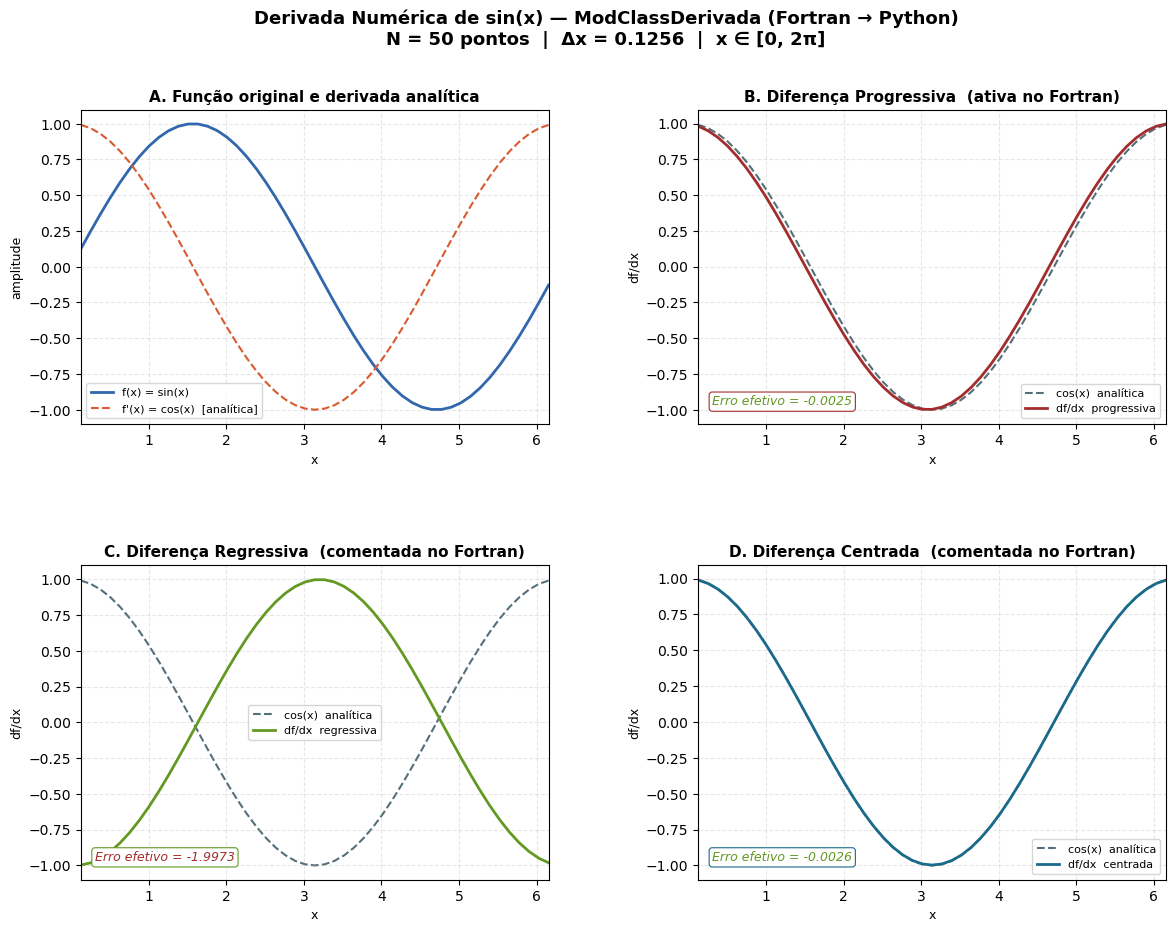

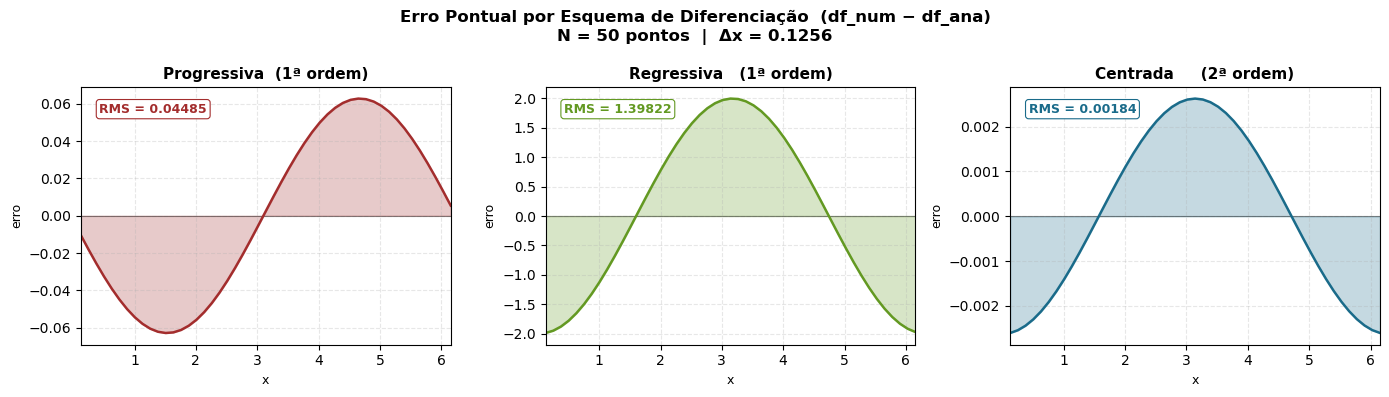

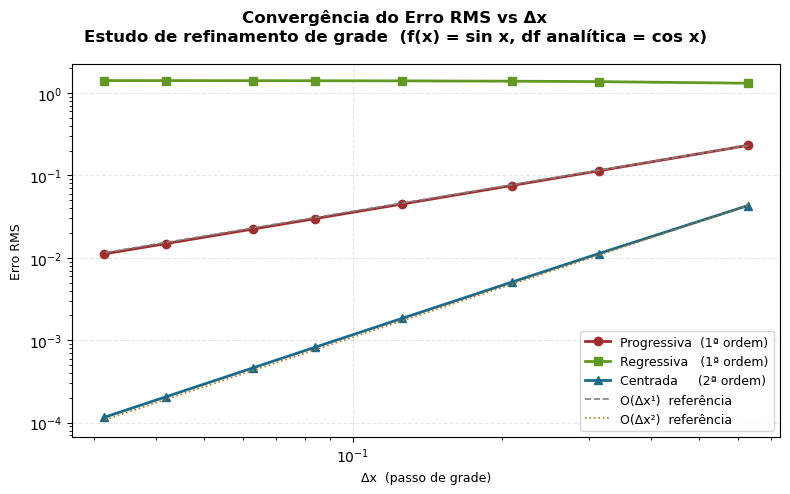

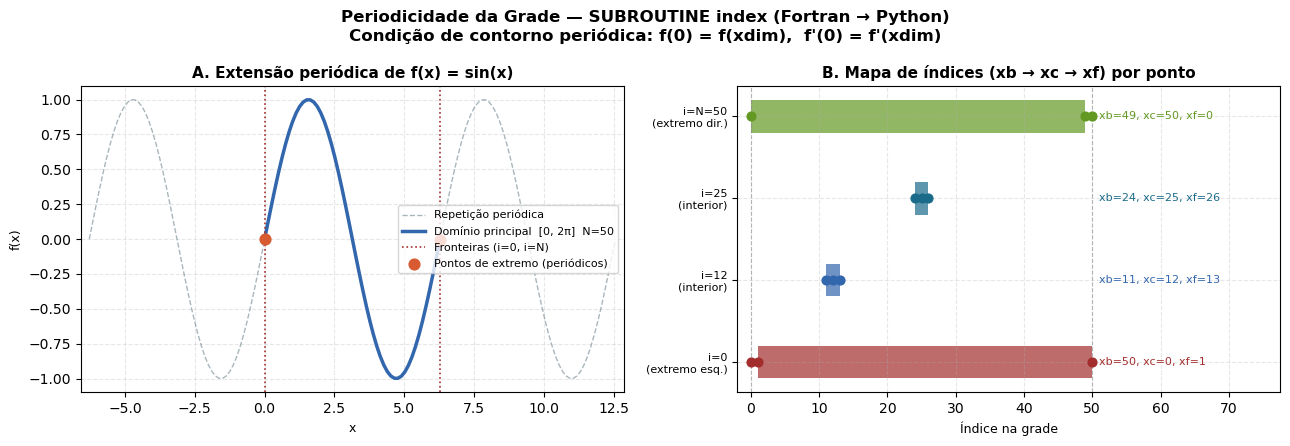

In [1]:
"""
=============================================================================
  Derivada Numérica — Conversão do Fortran ModClassDerivada para Python
=============================================================================

Corresponde fielmente à lógica do módulo Fortran:
  - InitClass   : define grade, f(x) = sin(x), ff(x) = cos(x)
  - runDeriv    : calcula df/dx com diferença progressiva (forward) e
                  compara com as alternativas comentadas no Fortran
                  (centrada e regressiva)
  - index()     : trata periodicidade nos extremos (condição de contorno)
  - Erro efetivo: SUM(df_num - df_ana) / SUM(df_ana)  [igual ao PRINT* Fortran]

Dependências:
    pip install numpy matplotlib
"""

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# =============================================================================
# CONFIGURAÇÃO GLOBAL
# =============================================================================
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor":   "white",
    "axes.grid":        True,
    "grid.alpha":       0.3,
    "grid.linestyle":   "--",
    "font.family":      "DejaVu Sans",
    "font.size":        10,
    "axes.titlesize":   11,
    "axes.titleweight": "bold",
    "axes.labelsize":   9,
})

NAVY   = "#0D2137"
TEAL   = "#1A6B8A"
BLUE   = "#3266ad"
ORANGE = "#d85a30"
GREEN  = "#639922"
RED    = "#a32d2d"
GRAY   = "#546E7A"
AMBER  = "#ba7517"
PURPLE = "#534ab7"

# =============================================================================
# EQUIVALENTE A: SUBROUTINE index(i, Idim, xb, xc, xf)
# Trata periodicidade: índice anterior, atual e próximo com contorno periódico
# =============================================================================
def index_periodic(i, idim):
    """
    Replicação exata da SUBROUTINE index do Fortran.
    Retorna (xb, xc, xf): índices anterior, atual e próximo com periodicidade.

    Fortran:
        IF(i==0)    → xb=Idim, xc=0,    xf=1
        IF(i==Idim) → xb=Idim-1, xc=Idim, xf=0
        ELSE        → xb=i-1, xc=i, xf=i+1
    """
    if i == 0:
        return idim, 0, 1
    elif i == idim:
        return idim - 1, idim, 0
    else:
        return i - 1, i, i + 1


# =============================================================================
# EQUIVALENTE A: SUBROUTINE InitClass
# =============================================================================
def init_class(xdim=50):
    """
    Inicializa a grade e as funções, exatamente como InitClass no Fortran.

    Fortran:
        Length = 2*Pi
        Dx     = Length / REAL(xdim)
        x(0)   = 0  (implícito — alocado zerado)
        x(xc)  = x(xb) + Dx   (loop i=1..xdim)
        f(xc)  = sin(x(xc))
        ff(xc) = cos(x(xc))
    """
    Pi     = 3.14                        # Mesmo valor do Fortran (REAL, PARAMETER :: Pi=3.14)
    Length = 2.0 * Pi
    dx     = Length / float(xdim)

    # Vetores de tamanho xdim+1: índices 0..xdim  (igual ao allocate(f(0:xdim)))
    x     = np.zeros(xdim + 1)
    f     = np.zeros(xdim + 1)
    ff    = np.zeros(xdim + 1)
    df2dx = np.zeros(xdim + 1)

    # Loop i=1..xdim para construir x (como no Fortran)
    # Fortran: CALL index(i,xdim,xb,xc,xf) → x(xc) = x(xb) + Dx
    # Para i=1..xdim-1: xb=i-1, xc=i  →  x[i] = x[i-1] + dx
    # Para i=xdim:      xb=xdim-1, xc=xdim  →  x[xdim] = x[xdim-1] + dx
    for i in range(1, xdim + 1):
        xb, xc, xf = index_periodic(i, xdim)
        x[xc] = x[xb] + dx

    # f e ff para todos os índices 0..xdim
    for i in range(xdim + 1):
        _, xc, _ = index_periodic(i, xdim)
        f[xc]  = np.sin(x[xc])
        ff[xc] = np.cos(x[xc])

    return x, f, ff, df2dx, dx, xdim


# =============================================================================
# EQUIVALENTE A: SUBROUTINE runDeriv — três esquemas de diferença
# =============================================================================
def run_deriv(x, f, ff, df2dx, dx, xdim, scheme="forward"):
    """
    Calcula a derivada numérica conforme os três esquemas comentados no Fortran.

    Fortran (ativo e comentados):
        df2dx(i) = ( F(xf) - F(xb) ) / (2*Dx)   ← centrada  (comentada)
        df2dx(i) = ( F(xf) - F(xc) ) / Dx        ← progressiva (ATIVA no Fortran)
        df2dx(i) = ( F(xb) - F(xc) ) / Dx        ← regressiva (comentada)

    Parâmetros
    ----------
    scheme : "forward"  (ativo no Fortran)
             "centered" (1ª linha comentada)
             "backward" (última linha comentada)
    """
    df = df2dx.copy()

    for i in range(xdim + 1):
        xb, xc, xf = index_periodic(i, xdim)
        if scheme == "centered":
            df[xc] = (f[xf] - f[xb]) / (2.0 * dx)
        elif scheme == "backward":
            df[xc] = (f[xb] - f[xc]) / dx
        else:                                         # "forward" — padrão Fortran
            df[xc] = (f[xf] - f[xc]) / dx

    # Erro efetivo — mesmo cálculo do PRINT* no Fortran
    # SUM(df2dx(1:xdim-1) - ff(1:xdim-1)) / SUM(ff(1:xdim-1))
    erro = (np.sum(df[1:xdim] - ff[1:xdim]) / np.sum(ff[1:xdim]))
    print(f"  [{scheme:>8}]  Effective Error = {erro:.6f}")

    return df, erro


# =============================================================================
# FIGURA 1 — Função original, derivada analítica e as três derivadas numéricas
# =============================================================================
def plot_derivadas(x, f, ff, xdim):
    """
    Plota a função original sin(x), a derivada analítica cos(x) e as três
    derivadas numéricas (progressiva, regressiva, centrada) em painéis separados.
    """
    fig = plt.figure(figsize=(14, 10))
    fig.suptitle(
        "Derivada Numérica de sin(x) — ModClassDerivada (Fortran → Python)\n"
        f"N = {xdim} pontos  |  Δx = {2*3.14/xdim:.4f}  |  x ∈ [0, 2π]",
        fontsize=13, fontweight="bold", y=0.98
    )
    gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.45, wspace=0.32)

    # ── Painel A: Função original ────────────────────────────────────────────
    ax0 = fig.add_subplot(gs[0, 0])
    xi = x[1:xdim]
    ax0.plot(xi, f[1:xdim],  color=BLUE,   lw=2.0, label="f(x) = sin(x)")
    ax0.plot(xi, ff[1:xdim], color=ORANGE, lw=1.5, ls="--", label="f'(x) = cos(x)  [analítica]")
    ax0.set_title("A. Função original e derivada analítica")
    ax0.set_xlabel("x")
    ax0.set_ylabel("amplitude")
    ax0.legend(fontsize=8)
    ax0.set_xlim(xi[0], xi[-1])

    # ── Painel B: Diferença progressiva (esquema ATIVO no Fortran) ───────────
    ax1 = fig.add_subplot(gs[0, 1])
    _, df_fw, err_fw = _calc_and_plot_scheme(ax1, x, f, ff, dx_val=2*3.14/xdim,
                                              xdim=xdim, scheme="forward",
                                              color=RED,
                                              title="B. Diferença Progressiva  (ativa no Fortran)",
                                              label_num="df/dx  progressiva")

    # ── Painel C: Diferença regressiva ───────────────────────────────────────
    ax2 = fig.add_subplot(gs[1, 0])
    _, df_bw, err_bw = _calc_and_plot_scheme(ax2, x, f, ff, dx_val=2*3.14/xdim,
                                              xdim=xdim, scheme="backward",
                                              color=GREEN,
                                              title="C. Diferença Regressiva  (comentada no Fortran)",
                                              label_num="df/dx  regressiva")

    # ── Painel D: Diferença centrada ─────────────────────────────────────────
    ax3 = fig.add_subplot(gs[1, 1])
    _, df_ct, err_ct = _calc_and_plot_scheme(ax3, x, f, ff, dx_val=2*3.14/xdim,
                                              xdim=xdim, scheme="centered",
                                              color=TEAL,
                                              title="D. Diferença Centrada  (comentada no Fortran)",
                                              label_num="df/dx  centrada")

    plt.savefig("fig_derivadas.png", dpi=150, bbox_inches="tight")
    print("Figura salva: fig_derivadas.png")
    return fig


def _calc_and_plot_scheme(ax, x, f, ff, dx_val, xdim, scheme, color, title, label_num):
    """Calcula um esquema e plota num eixo."""
    df2dx = np.zeros(xdim + 1)
    df, erro = run_deriv(x, f, ff, df2dx, dx_val, xdim, scheme=scheme)
    xi = x[1:xdim]

    ax.plot(xi, ff[1:xdim], color=GRAY,  lw=1.5, ls="--", label="cos(x)  analítica", zorder=1)
    ax.plot(xi, df[1:xdim], color=color, lw=2.0, label=label_num, zorder=2)
    ax.set_title(title)
    ax.set_xlabel("x")
    ax.set_ylabel("df/dx")
    ax.set_xlim(xi[0], xi[-1])
    ax.legend(fontsize=8)
    ax.annotate(
        f"Erro efetivo = {erro:.4f}",
        xy=(0.03, 0.06), xycoords="axes fraction",
        fontsize=9, color=RED if abs(erro) > 0.05 else GREEN,
        fontstyle="italic",
        bbox=dict(boxstyle="round,pad=0.25", facecolor="white", edgecolor=color, lw=0.8)
    )
    return ax, df, erro


# =============================================================================
# FIGURA 2 — Erro pontual de cada esquema
# =============================================================================
def plot_erros(x, f, ff, xdim):
    """
    Plota o erro pontual (df_num - df_ana) para os três esquemas.
    Ilustra visualmente a 1ª vs 2ª ordem de cada diferença.
    """
    dx_val = 2 * 3.14 / xdim
    df2dx  = np.zeros(xdim + 1)
    xi     = x[1:xdim]

    df_fw, _ = run_deriv(x, f, ff, df2dx.copy(), dx_val, xdim, scheme="forward")
    df_bw, _ = run_deriv(x, f, ff, df2dx.copy(), dx_val, xdim, scheme="backward")
    df_ct, _ = run_deriv(x, f, ff, df2dx.copy(), dx_val, xdim, scheme="centered")

    err_fw = df_fw[1:xdim] - ff[1:xdim]
    err_bw = df_bw[1:xdim] - ff[1:xdim]
    err_ct = df_ct[1:xdim] - ff[1:xdim]

    fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=False)
    fig.suptitle(
        "Erro Pontual por Esquema de Diferenciação  (df_num − df_ana)\n"
        f"N = {xdim} pontos  |  Δx = {dx_val:.4f}",
        fontsize=12, fontweight="bold"
    )

    data = [
        (axes[0], err_fw, RED,   "Progressiva  (1ª ordem)",  "forward"),
        (axes[1], err_bw, GREEN, "Regressiva   (1ª ordem)",  "backward"),
        (axes[2], err_ct, TEAL,  "Centrada     (2ª ordem)",  "centered"),
    ]

    for ax, err, color, label, scheme in data:
        ax.axhline(0, color="black", lw=0.8, alpha=0.4)
        ax.fill_between(xi, err, alpha=0.25, color=color)
        ax.plot(xi, err, color=color, lw=1.8, label=label)
        ax.set_title(label)
        ax.set_xlabel("x")
        ax.set_ylabel("erro")
        ax.set_xlim(xi[0], xi[-1])
        rms = np.sqrt(np.mean(err**2))
        ax.annotate(
            f"RMS = {rms:.5f}",
            xy=(0.05, 0.90), xycoords="axes fraction",
            fontsize=9, color=color, fontweight="bold",
            bbox=dict(boxstyle="round,pad=0.25", facecolor="white", edgecolor=color, lw=0.8)
        )

    plt.tight_layout()
    plt.savefig("fig_erros.png", dpi=150, bbox_inches="tight")
    print("Figura salva: fig_erros.png")
    return fig


# =============================================================================
# FIGURA 3 — Convergência: erro RMS vs N (estudo de refinamento de grade)
# =============================================================================
def plot_convergencia():
    """
    Estuda como o erro RMS diminui com o refinamento da grade (N crescente).
    Diferença progressiva/regressiva → O(Δx¹); centrada → O(Δx²).
    Reproduz o comportamento esperado da teoria de diferenças finitas.
    """
    N_vals = [10, 20, 30, 50, 75, 100, 150, 200]
    rms_fw, rms_bw, rms_ct = [], [], []

    for N in N_vals:
        x_, f_, ff_, df2dx_, dx_, _ = init_class(xdim=N)
        df_fw, _ = run_deriv(x_, f_, ff_, df2dx_.copy(), dx_, N, scheme="forward")
        df_bw, _ = run_deriv(x_, f_, ff_, df2dx_.copy(), dx_, N, scheme="backward")
        df_ct, _ = run_deriv(x_, f_, ff_, df2dx_.copy(), dx_, N, scheme="centered")
        rms_fw.append(np.sqrt(np.mean((df_fw[1:N] - ff_[1:N])**2)))
        rms_bw.append(np.sqrt(np.mean((df_bw[1:N] - ff_[1:N])**2)))
        rms_ct.append(np.sqrt(np.mean((df_ct[1:N] - ff_[1:N])**2)))

    dx_vals = [2 * 3.14 / N for N in N_vals]

    fig, ax = plt.subplots(figsize=(8, 5))
    fig.suptitle(
        "Convergência do Erro RMS vs Δx\n"
        "Estudo de refinamento de grade  (f(x) = sin x, df analítica = cos x)",
        fontsize=12, fontweight="bold"
    )

    ax.loglog(dx_vals, rms_fw, color=RED,   lw=2, marker="o", ms=6, label="Progressiva  (1ª ordem)")
    ax.loglog(dx_vals, rms_bw, color=GREEN, lw=2, marker="s", ms=6, label="Regressiva   (1ª ordem)")
    ax.loglog(dx_vals, rms_ct, color=TEAL,  lw=2, marker="^", ms=6, label="Centrada     (2ª ordem)")

    # Linhas de referência de ordem 1 e 2
    dx_ref = np.array([dx_vals[0], dx_vals[-1]])
    scale1 = rms_fw[0] / dx_vals[0]**1
    scale2 = rms_ct[0] / dx_vals[0]**2
    ax.loglog(dx_ref, scale1 * dx_ref**1, color="gray",   lw=1.2, ls="--", label="O(Δx¹)  referência")
    ax.loglog(dx_ref, scale2 * dx_ref**2, color=AMBER,    lw=1.2, ls=":",  label="O(Δx²)  referência")

    ax.set_xlabel("Δx  (passo de grade)")
    ax.set_ylabel("Erro RMS")
    ax.legend(fontsize=9)
    ax.set_title("")

    plt.tight_layout()
    plt.savefig("fig_convergencia.png", dpi=150, bbox_inches="tight")
    print("Figura salva: fig_convergencia.png")
    return fig


# =============================================================================
# FIGURA 4 — Efeito da periodicidade (função index)
# =============================================================================
def plot_periodicidade(x, f, ff, xdim):
    """
    Ilustra o papel da SUBROUTINE index: como os índices xb/xc/xf
    tratam a periodicidade nos extremos (i=0 e i=xdim).
    """
    dx_val = 2 * 3.14 / xdim
    xi     = x[0:xdim + 1]
    fi     = f[0:xdim + 1]

    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
    fig.suptitle(
        "Periodicidade da Grade — SUBROUTINE index (Fortran → Python)\n"
        "Condição de contorno periódica: f(0) = f(xdim),  f'(0) = f'(xdim)",
        fontsize=12, fontweight="bold"
    )

    # Painel esquerdo: f(x) extendida com os pontos fantasma
    ax = axes[0]
    # Cria extensão periódica manual para visualização
    x_ext = np.concatenate([xi - 2*3.14, xi, xi + 2*3.14])
    f_ext = np.concatenate([fi, fi, fi])
    ax.plot(x_ext, f_ext, color=GRAY,  lw=1.0, ls="--", alpha=0.5, label="Repetição periódica")
    ax.plot(xi,    fi,    color=BLUE,  lw=2.5, label=f"Domínio principal  [0, 2π]  N={xdim}")
    ax.axvline(x[0],    color=RED,   lw=1.2, ls=":", label="Fronteiras (i=0, i=N)")
    ax.axvline(x[xdim], color=RED,   lw=1.2, ls=":")
    ax.scatter([x[0], x[xdim]], [f[0], f[xdim]], color=ORANGE, s=60, zorder=5,
               label="Pontos de extremo (periódicos)")
    ax.set_title("A. Extensão periódica de f(x) = sin(x)")
    ax.set_xlabel("x")
    ax.set_ylabel("f(x)")
    ax.set_xlim(-2*3.14 - 0.3, 2*3.14*2 + 0.3)
    ax.legend(fontsize=8)

    # Painel direito: mapa de índices (xb, xc, xf) para i=0, N e interior
    ax = axes[1]
    exemplos = [
        (0,         "i=0\n(extremo esq.)",  RED),
        (xdim//4,   f"i={xdim//4}\n(interior)", BLUE),
        (xdim//2,   f"i={xdim//2}\n(interior)", TEAL),
        (xdim,      f"i=N={xdim}\n(extremo dir.)", GREEN),
    ]
    y_pos = np.arange(len(exemplos))
    for k, (i, label, color) in enumerate(exemplos):
        xb, xc, xf = index_periodic(i, xdim)
        ax.barh(k, xf - xb, left=xb, height=0.4, color=color, alpha=0.7)
        ax.scatter([xb, xc, xf], [k, k, k], color=color, s=40, zorder=5)
        ax.text(xdim * 1.02, k, f"xb={xb}, xc={xc}, xf={xf}", va="center", fontsize=8, color=color)

    ax.set_yticks(y_pos)
    ax.set_yticklabels([e[1] for e in exemplos], fontsize=8)
    ax.set_xlabel("Índice na grade")
    ax.set_title("B. Mapa de índices (xb → xc → xf) por ponto")
    ax.set_xlim(-2, xdim + xdim * 0.55)
    ax.axvline(0,     color="gray", lw=0.8, ls="--", alpha=0.5)
    ax.axvline(xdim,  color="gray", lw=0.8, ls="--", alpha=0.5)

    plt.tight_layout()
    plt.savefig("fig_periodicidade.png", dpi=150, bbox_inches="tight")
    print("Figura salva: fig_periodicidade.png")
    return fig


# =============================================================================
# PROGRAMA PRINCIPAL — equivalente ao PROGRAM Main do Fortran
# =============================================================================
def main():
    print("=" * 60)
    print("  ModClassDerivada — Fortran → Python")
    print("=" * 60)

    # Init (equivalente a CALL InitClass)
    print("\n[Init]")
    x, f, ff, df2dx, dx, xdim = init_class(xdim=50)
    print(f"  xdim = {xdim}")
    print(f"  dx   = {dx:.6f}")
    print(f"  x ∈  [{x[1]:.4f}, {x[xdim-1]:.4f}]")

    # Run (equivalente a CALL runDeriv — todos os esquemas)
    print("\n[Run — Effective Error por esquema]")
    run_deriv(x, f, ff, df2dx.copy(), dx, xdim, scheme="forward")    # ativo no Fortran
    run_deriv(x, f, ff, df2dx.copy(), dx, xdim, scheme="backward")   # comentado
    run_deriv(x, f, ff, df2dx.copy(), dx, xdim, scheme="centered")   # comentado

    # Figuras
    print("\n[Gerando figuras]")
    plot_derivadas(x, f, ff, xdim)
    plot_erros(x, f, ff, xdim)
    plot_convergencia()
    plot_periodicidade(x, f, ff, xdim)

    print("\n[Finalize — memória liberada pelo GC Python]")
    print("Concluído.")


if __name__ == "__main__":
    main()